# Assignment 2
We first start by importing the libraries we need:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

Now we read the survivors dataset

In [2]:
survivors = pd.read_csv('files/ch02/survivors.csv',na_values=':',usecols = ["Survived","Pclass","Name","Sex","Age","SibSp","Parch","Ticket","Fare","Cabin","Embarked"])
survivors.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Use of descriptive statistics on our dataset

In [3]:
survivors.shape

(891, 11)

In [4]:
survivors.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
survivors.dtypes

Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object

## Handling missing values

In [6]:
survivors.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [7]:
missing_values = survivors.isnull().sum().sort_values(ascending =False)
percentage_missing_values= (missing_values/len(survivors)) * 100
pd.concat([missing_values, percentage_missing_values], axis = 1, keys= ['Missing values', '% Missing'])

,Missing values,% Missing
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000
Fare,0,0.000000


The cabin column have the highest amount of missing values and that leads us to dropping that column and the **Embarked** column needs to have the small percentage of its missing values replaces with the char 'U', with the **Age** replaced with the median age

In [8]:
survivors.drop(['Cabin','Ticket'],axis=1,inplace=True)
survivors['Age']=survivors['Age'].fillna(survivors['Age'].median())
survivors['Embarked']=survivors['Embarked'].fillna('U')


In [9]:
survivors.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


## Clean the data

Now we need to clean our data by converting the sex and embarked columns appropiately

In [10]:
print(f"Sex:{survivors['Sex'].unique()}\n")
print(f"Embarked:{survivors['Embarked'].unique()}\n")
print(f"Name:{survivors['Name'].unique()}\n")
print(f"Pclass:{survivors['Pclass'].unique()}\n")

Sex:<StringArray>
['male', 'female']
Length: 2, dtype: str

Embarked:<StringArray>
['S', 'C', 'Q', 'U']
Length: 4, dtype: str

Name:<StringArray>
[                            'Braund, Mr. Owen Harris',
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
                              'Heikkinen, Miss. Laina',
        'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
                            'Allen, Mr. William Henry',
                                    'Moran, Mr. James',
                             'McCarthy, Mr. Timothy J',
                      'Palsson, Master. Gosta Leonard',
   'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
                 'Nasser, Mrs. Nicholas (Adele Achem)',
 ...
                                  'Markun, Mr. Johann',
                        'Dahlberg, Miss. Gerda Ulrika',
                       'Banfield, Mr. Frederick James',
                              'Sutehall, Mr. Henry Jr',
                'Rice, Mrs. William (Margaret Norton)',
         

## Converting objects into numerical values

In [11]:
le =LabelEncoder()

survivors['Embarked']=le.fit_transform(survivors['Embarked'])
survivors['Sex']=le.fit_transform(survivors['Sex'])

survivors.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,2


## Histogram for the Passenger Age Groups

The age distribution is right-skewed, with the majority of passengers falling between the ages of 20 and 40. The most frequent age group is 24–28 years old **(high frequency)**. There is also a small peak for children aged 0–5, indicating a significant number of infants. Conversely, passengers over the age of 70 were very rare, representing the lowest portion of the population onboard **(low frequency)**.

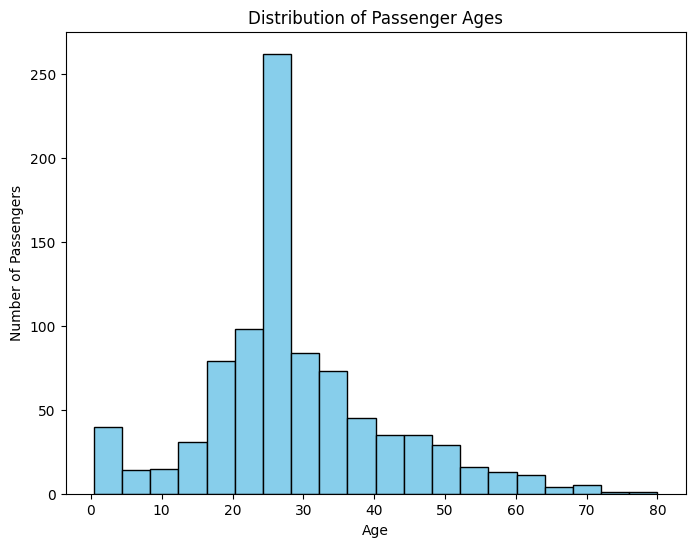

In [12]:
plt.figure(figsize=(8,6))
plt.hist(survivors['Age'],bins=20,color='skyblue',edgecolor='black')

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## Bar Char for Passenger Class

The bar char has a high frequency of passngers the the 3rd class, followed by the 1st and 2nd class. Over 450 passengers are in the 3rd class, which is more than both 1st and 2nd classes combined. This indicates why a high number of deaths occured in this category, simply because there were more people there. It also worth noting the 3rd class was carring low income passengers(immigrants, workers, etc)

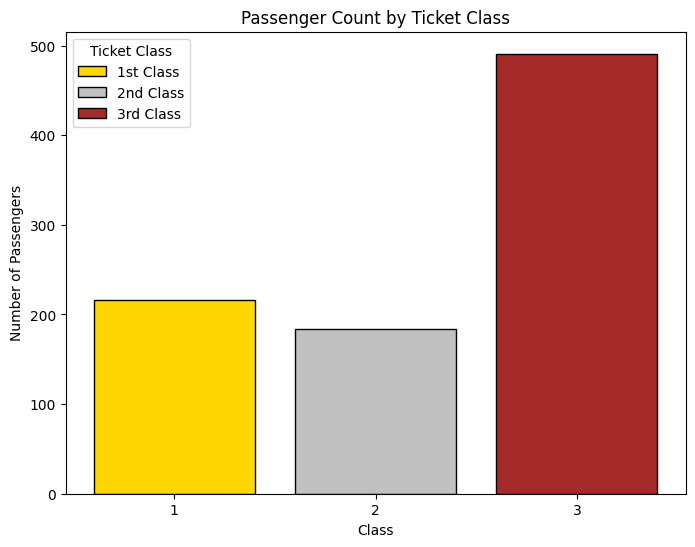

In [13]:
classes = ['1st Class', '2nd Class', '3rd Class']
counts = survivors['Pclass'].value_counts().sort_index()
colors = ['gold', 'silver', 'brown'] # Distinct colors for each class

# Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='black')

plt.legend(bars, classes, title="Ticket Class")

plt.title('Passenger Count by Ticket Class')
plt.xlabel('Class')
plt.ylabel('Number of Passengers')
plt.show()

## Heatmap for the survival rate across Sex and Passenger class

The heatmap reveals a strong correlation between survival, gender, and ticket class.

1. ***First class:*** 97% of the females survived in this class while 37% of males survied, showcasing that females had the highest survival in this class
2. **Second class:** 92% of the females survived in this class while 16% of the males survived, a lower percentage than the first class.
3. ***Third class:*** 50% of the females survived in this class while 14% of the males survived. even lower than the second class.

Compared to females, the males had the lowest chance of survivals as you go down from first class, while females survival rate was higher in the first and second class, it dropped as well in 3rd class, it appears that the males had the highest chance of survival in the first class compared to the 3rd class. This is also true for females as well.

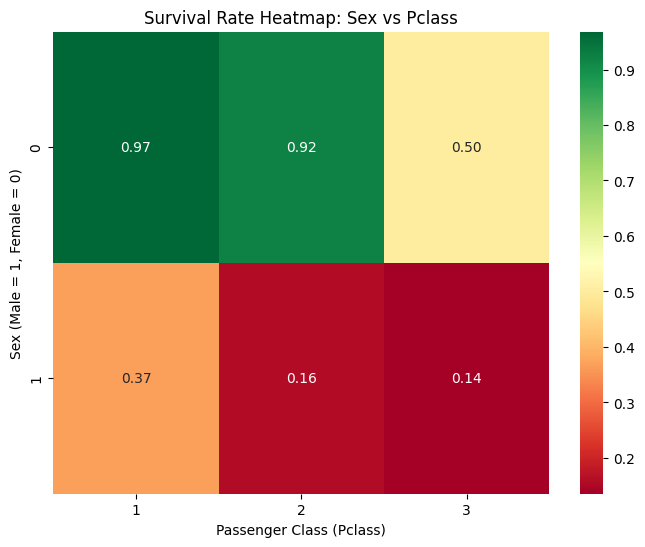

In [14]:
survival_pivot = survivors.pivot_table(values='Survived', index='Sex', columns='Pclass')

plt.figure(figsize=(8, 6))
sns.heatmap(survival_pivot, annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('Survival Rate Heatmap: Sex vs Pclass')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Sex (Male = 1, Female = 0)')
plt.show()

## Scatter plot for Age vs Fare

The scatter plot below highlights that the Fare was a more significant predictor of survival than Age for adults. While children (0-10) showed high survival rates across various fare brackets, survival for adults was heavily concentrated among those who paid higher fares. The high density of deceased passengers in the low-fare, 20-40 age range suggests that 3rd-class young adults were the most at-risk demographic.

plt.figure(figsize=(10, 7))

sns.scatterplot(x='Age', y='Fare', hue='Survived', data=survivors, palette={0: 'red', 1: 'green'}, alpha=0.7)

plt.title('Scatter Plot: Age vs. Fare (Colored by Survival)')
plt.xlabel('Age (Years)')
plt.ylabel('Fare (Price)')


## Pie Chart for female and male survival rates

Both pie charts illustrate the survival rates between male and females. 

### Female Pie Chart
The female survival rate in the pie chart illustrates that 81.1% of females survived, while 18.9% of them died.

### Male Pie Chart
The male survival rate shows us that 742% os males died while 25.8% survived

***In conclusion:*** between both male and females, a high percentage of females survvived as compared to males

In [19]:
survivors[survivors['Sex'] == 1]['Survived'].head(10)

0     0
4     0
5     0
6     0
7     0
12    0
13    0
16    0
17    1
20    0
Name: Survived, dtype: int64

Text(0.5, 1.0, 'Male Survival Rate')

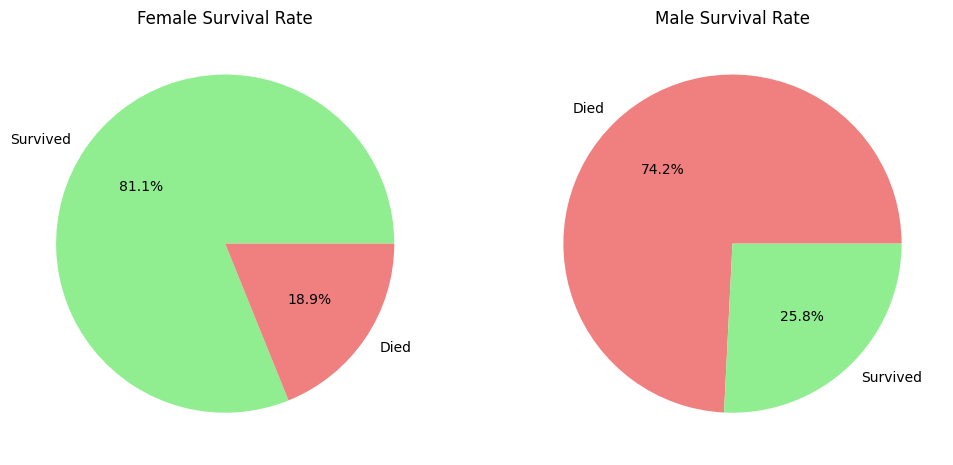

In [16]:

female_survived = survivors[survivors['Sex'] == 1]['Survived'].value_counts()
male_survived = survivors[survivors['Sex'] == 0]['Survived'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(female_survived, labels=['Survived', 'Died'], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
ax1.set_title('Female Survival Rate')

ax2.pie(male_survived, labels=['Died', 'Survived'], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
ax2.set_title('Male Survival Rate')

## Pie Chart for Passenger class survival

### First class pie chart
In the first class 63% of the passengers survived while 37% of the passengers died

### Second class pie chart
In the second class 52.7% of the passengers died while 47.3% of the passengers survived

### Third class pie chart
In the third class 75.8% of the passengers died while 24.2.% of the passengers survived

Amongst the 3 passenger classes, the first class has the highest rate of survival for the passengers while the 3rd class had the lowest rate of survival which can be said that majority of these passengers are male

Text(0.5, 1.0, '3rd Class Survival')

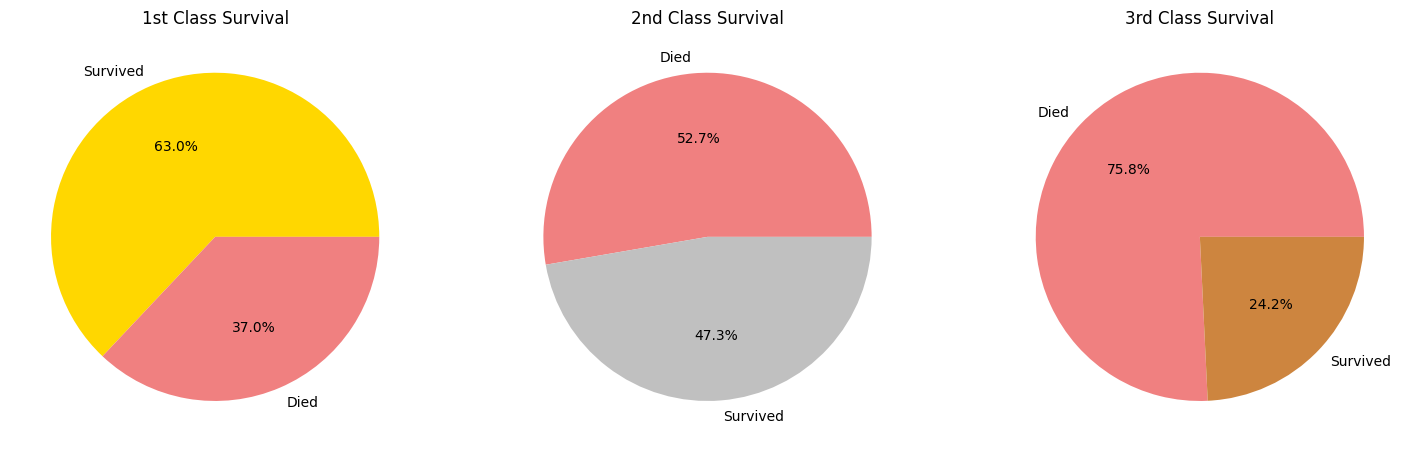

In [17]:
p1_survived = survivors[survivors['Pclass'] == 1]['Survived'].value_counts()
p2_survived = survivors[survivors['Pclass'] == 2]['Survived'].value_counts()
p3_survived = survivors[survivors['Pclass'] == 3]['Survived'].value_counts()

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

ax1.pie(p1_survived, labels=['Survived', 'Died'], autopct='%1.1f%%', colors=['gold', 'lightcoral'])
ax1.set_title('1st Class Survival')

ax2.pie(p2_survived, labels=['Died', 'Survived'], autopct='%1.1f%%', colors=['lightcoral', 'silver'])
ax2.set_title('2nd Class Survival')

ax3.pie(p3_survived, labels=['Died', 'Survived'], autopct='%1.1f%%', colors=['lightcoral', 'peru'])
ax3.set_title('3rd Class Survival')

## Additional features

In [18]:
survivors['Title']=survivors['Name'].str.extract('([A-Za-z]+)\.',expand=False)
survivors.head()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\mnqob\AppData\Local\Temp\ipykernel_21512\144730232.py:1: SyntaxWarning: invalid escape sequence '\.'
  survivors['Title']=survivors['Name'].str.extract('([A-Za-z]+)\.',expand=False)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0,Mrs
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2,Mrs
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,2,Mr


In [19]:
print(f"Title: {survivors['Title'].unique()}")

Title: <StringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer']
Length: 17, dtype: str


In [20]:
survivors['Title'] = survivors['Title'].replace(['Ms', 'Mlle'], 'Miss')
survivors['Title'] = survivors['Title'].replace(['Mme'], 'Mrs')
survivors['Title'] = survivors['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Jonkheer', 'Don', 'Sir', 'Lady', 'Countess'], 'Rare')

print(survivors['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


Now we need to categorizr the titles according to the specs of Miss, Mrs, Mr and Rare

In [21]:
le = LabelEncoder()
survivors['Title']=le.fit_transform(survivors['Title'])

survivors[['Name','Title']].head()

,Name,Title
0,"Braund, Mr. Owen Harris",2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",3
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",3
4,"Allen, Mr. William Henry",2


In [22]:
survivors['FamilySize']=survivors['SibSp']+survivors['Parch']+1
survivors.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2,2,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0,3,2
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2,3,2
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,2,2,1


## Irrelevant column
The name column is also irrelevant since we have extracted the data we requre from it

In [23]:
survivors.drop(['Name'],axis=1,inplace=True)
survivors.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,1,22.0,1,0,7.2500,2,2,2
1,1,1,0,38.0,1,0,71.2833,0,3,2
2,1,3,0,26.0,0,0,7.9250,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,3,2
4,0,3,1,35.0,0,0,8.0500,2,2,1


## Outliers and correlation

Now that our values in the dataset are numerical, we can apply the appropiate descriptive statistics to analyze our dataset

In [24]:
# Median age
median_age=survivors['Age'].median()

print('Our mean age for the dataset of survivors is: ',median_age)

Our mean age for the dataset of survivors is:  28.0


### Mean age for both male and female survivors grouped by class

In [25]:
## Male =1, Female =0
stats=survivors.groupby(['Sex','Pclass'])['Age'].mean()
print(stats)

Sex  Pclass
0    1         33.978723
     2         28.703947
     3         23.572917
1    1         38.995246
     2         30.512315
     3         26.911873
Name: Age, dtype: float64


### Variance age for both male and female survivors grouped by class

In [26]:
## Male =1, Female =0
stats=survivors.groupby(['Sex','Pclass'])['Age'].var()
print(stats)

Sex  Pclass
0    1         171.182338
     2         161.301184
     3         122.582933
1    1         214.771352
     2         201.029723
     3         108.126594
Name: Age, dtype: float64


### Standard deviation age for both male and female survivors grouped by class

In [27]:
## Male =1, Female =0
stats=survivors.groupby(['Sex','Pclass'])['Age'].std()
print(stats)

Sex  Pclass
0    1         13.083667
     2         12.700440
     3         11.071718
1    1         14.655079
     2         14.178495
     3         10.398394
Name: Age, dtype: float64


*We will now calculate outlier by calculating the data that lies outside our lower bound and upper bound*

In [28]:
Q1 = survivors['Age'].quantile(0.25)
Q3 = survivors['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = survivors[(survivors['Age'] < lower_bound) | (survivors['Age'] > upper_bound)]
print(outliers)

     Survived  Pclass  Sex    Age  SibSp  Parch     Fare  Embarked  Title  \
7           0       3    1   2.00      3      1  21.0750         2      0   
11          1       1    0  58.00      0      0  26.5500         2      1   
15          1       2    0  55.00      0      0  16.0000         2      3   
16          0       3    1   2.00      4      1  29.1250         1      0   
33          0       2    1  66.00      0      0  10.5000         2      2   
..        ...     ...  ...    ...    ...    ...      ...       ...    ...   
827         1       2    1   1.00      0      2  37.0042         0      0   
829         1       1    0  62.00      0      0  80.0000         3      3   
831         1       2    1   0.83      1      1  18.7500         2      0   
851         0       3    1  74.00      0      0   7.7750         2      2   
879         1       1    0  56.00      0      1  83.1583         0      3   

     FamilySize  
7             5  
11            1  
15            1  
16 

In [29]:
# Mean with all data (including outliers)
mean_with_outliers = survivors['Age'].mean()


med_age = survivors['Age'].median()
upper_limit = med_age + 35
lower_limit = med_age - 15

# Filter the data (Removing the outliers)
cleaned_data = survivors[(survivors['Age'] <= upper_limit) & (survivors['Age'] >= lower_limit)]
mean_without_outliers = cleaned_data['Age'].mean()

#  Calculating the Difference
difference = mean_with_outliers - mean_without_outliers

print(f"Mean with Outliers: {mean_with_outliers}")
print(f"Mean without Outliers: {mean_without_outliers}")
print(f"The 'Pull' of Outliers: {difference} years")

Mean with Outliers: 29.36158249158249
Mean without Outliers: 30.823856613102596
The 'Pull' of Outliers: -1.4622741215201067 years


As we can see above, the mean with outliers is actually higher than that without outliers, this explains the massive spike of the histogram at the younger end of the scale. Meaning a higher number of younger children and adults were saved

## Correlation between values

In [30]:
survivors.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
Survived,1.000000,-0.338481,-0.543351,-0.064910,-0.035322,0.081629,0.257307,-0.163517,-0.071174,0.016639
Pclass,-0.338481,1.000000,0.131900,-0.339898,0.083081,0.018443,-0.549500,0.157112,-0.181177,0.065997
Sex,-0.543351,0.131900,1.000000,0.081163,-0.114631,-0.245489,-0.182333,0.104057,0.060299,-0.200988
Age,-0.064910,-0.339898,0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.014205,0.476260,-0.245619
SibSp,-0.035322,0.083081,-0.114631,-0.233296,1.000000,0.414838,0.159651,0.066654,-0.209813,0.890712
Parch,0.081629,0.018443,-0.245489,-0.172482,0.414838,1.000000,0.216225,0.038322,-0.117587,0.783111
Fare,0.257307,-0.549500,-0.182333,0.096688,0.159651,0.216225,1.000000,-0.221226,-0.013273,0.217138
Embarked,-0.163517,0.157112,0.104057,-0.014205,0.066654,0.038322,-0.221226,1.000000,0.005564,0.064701
Title,-0.071174,-0.181177,0.060299,0.476260,-0.209813,-0.117587,-0.013273,0.005564,1.000000,-0.202145
FamilySize,0.016639,0.065997,-0.200988,-0.245619,0.890712,0.783111,0.217138,0.064701,-0.202145,1.000000


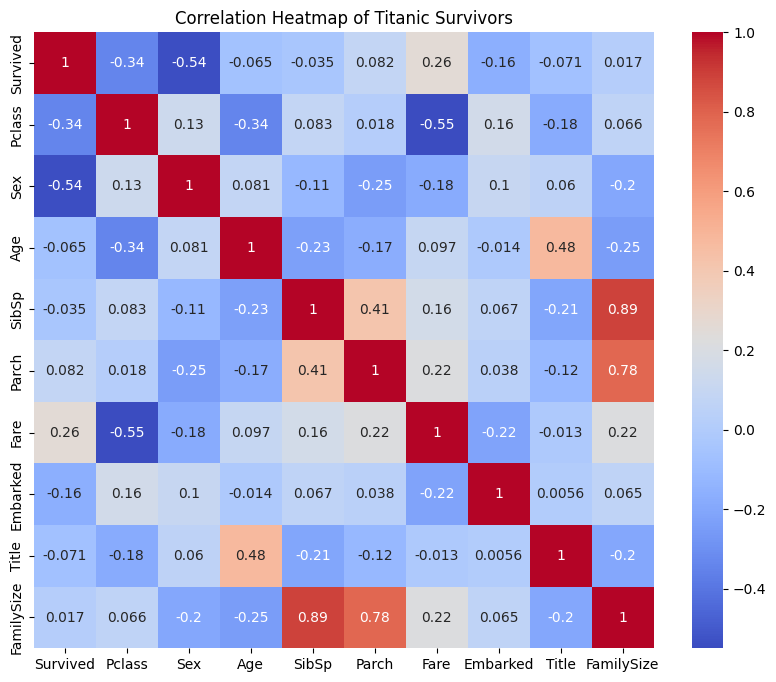

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(survivors.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Titanic Survivors')
plt.show()

## Analyis:

- The correlation between sex and survival is **-0.54**, a negative correlation which means that as the 'Sex' numnber goes up(becomes male), the survival rate goes down, a good insight of 'Women and children first policy'
- The correlation between Pclass and Fare is **-0.55**, also a negative correlation indicating that as the Class increases, the lower the fair paid
- Other notes are the Family factor, SibSp and Parch
- SibSp and FamilySize have a correlation of 0.89
- Parch and FamilySize have a correlation of 0.78
- This means that the correlation betweem family factors are valid, althogh with the FamilySize itself and survival, the correlation is 0.0016, suggesting that having a big family doesn't necessarily ensure survival.

In [32]:
# Saving the survivor subset specifically
survivors.to_csv('clean_survivors.csv', index=False)

## End of Assignment